In [1]:
#1 Implementing Softmax Function:
import numpy as np
def softmax(z):
    """
    Compute the softmax of a 2D numpy array.
    """
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


In [6]:
# Test Case:
def test_softmax():
    test_cases = [
        (np.array([[0, 0, 0]]), "All zeros"),
        (np.array([[1, 2, 3]]), "Simple case"),
        (np.array([[1000, 1000, 1000]]), "Large identical values"),
        (np.array([[-1000, -1000, -1000]]), "Small identical values"),
        (np.array([[1, 0, -1]]), "Mixed positive and negative")
    ]
    for i, (z, description) in enumerate(test_cases):
        print(f"Test {i + 1}: {description}")
        result = softmax(z)
        assert np.allclose(result.sum(axis=1), 1), f"Failed: Probabilities do not sum to 1 in {description}"
        assert np.all(result >= 0), f"Failed: Negative probabilities in {description}"
    print("All tests passed for softmax function.")
test_softmax()

Test 1: All zeros
Test 2: Simple case
Test 3: Large identical values
Test 4: Small identical values
Test 5: Mixed positive and negative
All tests passed for softmax function.


In [8]:
#2 Implementation of categorical log-loss function:
def loss_softmax(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-10))

In [11]:
# Test Case:
def test_loss_softmax():
    # Perfect prediction test case:
    y_true = np.array([0, 1, 0])
    y_pred = np.array([0.1, 0.8, 0.1])
    expected_loss = -np.log(0.8)
    assert np.isclose(loss_softmax(y_true, y_pred), expected_loss), "Test Case 1 Failed"
    # Incorrect prediction test case:
    y_true = np.array([1, 0, 0])
    y_pred = np.array([0.3, 0.4, 0.3])
    expected_loss = -np.log(0.3)
    assert np.isclose(loss_softmax(y_true, y_pred), expected_loss), "Test Case 2 Failed"
    # Edge case with near-zero probability
    y_true = np.array([0, 1, 0])
    y_pred = np.array([0.01, 0.98, 0.01])
    expected_loss = -np.log(0.98)
    assert np.isclose(loss_softmax(y_true, y_pred), expected_loss), "Test Case 3 Failed"
    print("All test cases passed!")
test_loss_softmax()

All test cases passed!


In [14]:
#3 Implementation of cost function:
# Cost Function for Softmax (Average Loss)
def cost_softmax(X, y, W, b):
    n, d = X.shape
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    return -np.sum(y * np.log(y_pred + 1e-10)) / n

In [15]:
# Test Case:
import numpy as np
def test_cost_softmax():
    # Test Case 1: Small dataset with perfect predictions
    X = np.array([[1, 2], [2, 3], [3, 4]])
    y = np.array([[1, 0], [0, 1], [1, 0]])
    W = np.array([[1, -1], [-1, 1]])
    b = np.array([0, 0])
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    expected_cost = -np.sum(y * np.log(y_pred + 1e-10)) / X.shape[0]
    assert np.isclose(cost_softmax(X, y, W, b), expected_cost), "Test Case 1 Failed"
    # Test Case 2: All-zero weights and bias
    X = np.array([[1, 0], [0, 1], [1, 1]])
    y = np.array([[1, 0], [0, 1], [1, 0]])
    W = np.zeros((2, 2))
    b = np.zeros(2)
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    expected_cost = -np.sum(y * np.log(y_pred + 1e-10)) / X.shape[0]
    assert np.isclose(cost_softmax(X, y, W, b), expected_cost), "Test Case 2 Failed"
    print("All test cases passed!")
test_cost_softmax()

All test cases passed!


In [18]:
#4.1 Computing Gradients for Softmax Regression:
# Gradient Computation
import numpy as np
def compute_gradient_softmax(X, y, W, b):
    n, d = X.shape
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n
    return grad_W, grad_b

In [17]:
# Test Case:
def test_compute_gradient_softmax():
    X = np.array([[1, 2], [3, 4]])
    y = np.array([[1, 0], [0, 1]]) 
    W = np.array([[0.1, 0.2], [0.3, 0.4]]) 
    b = np.array([0.01, 0.02]) # Shape (2,)
    # Expected gradients (calculated manually or using a reference implementation)
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    grad_W_expected = np.dot(X.T, (y_pred - y)) / X.shape[0]
    grad_b_expected = np.sum(y_pred - y, axis=0) / X.shape[0]
    # Computing gradients using the function
    grad_W, grad_b = compute_gradient_softmax(X, y, W, b)
    assert np.allclose(grad_W, grad_W_expected, atol=1e-6), "Gradient W does not match expected values"
    assert np.allclose(grad_b, grad_b_expected, atol=1e-6), "Gradient b does not match expected values"
    print("All tests passed for compute_gradient_softmax!")
test_compute_gradient_softmax()

All tests passed for compute_gradient_softmax!


In [21]:
#4.2 Gradient Descent for Softmax Regresssion:
# Gradient Descent
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []
    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)
        W -= alpha * grad_W
        b -= alpha * grad_b
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)
        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i}: Cost = {cost:.6f}")
    return W, b, cost_history

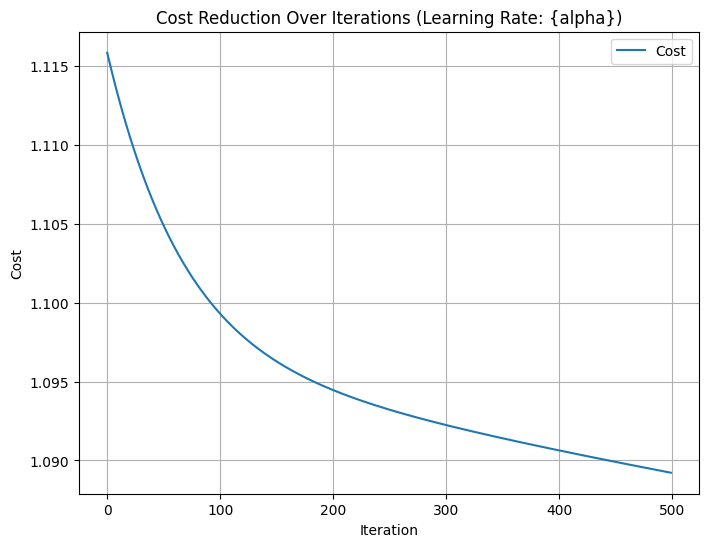

Initial Cost: 1.1158608479596404
Final Cost: 1.0892233754862581


In [23]:
# Test Case:
import matplotlib.pyplot as plt
def test_gradient_descent_softmax_with_plot():
    # Generating synthetic data for testing
    np.random.seed(0)
    n, d, c = 100, 5, 3 # 100 samples, 5 features, 3 classes
    X = np.random.rand(n, d)
    y_indices = np.random.randint(0, c, size=n)
    y = np.zeros((n, c))
    y[np.arange(n), y_indices] = 1 # One-hot encoding
    # Initializing weights and biases
    W = np.random.rand(d, c)
    b = np.random.rand(c)
    # Parameters for gradient descent
    alpha = 0.01 # Learning rate
    n_iter = 500 # Number of iterations
    # Running gradient descent
    W_opt, b_opt, cost_history = gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False)
    # Plotting the cost history
    plt.figure(figsize=(8, 6))
    plt.plot(range(n_iter), cost_history, label="Cost")
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.title("Cost Reduction Over Iterations (Learning Rate: {alpha})")
    plt.legend()
    plt.grid()
    plt.show()
    # Final cost should ideally be less than initial cost
    print(f"Initial Cost: {cost_history[0]}")
    print(f"Final Cost: {cost_history[-1]}")
test_gradient_descent_softmax_with_plot()

In [25]:
#5 Decision/Prediction Function:
import numpy as np
def predict_softmax(X, W, b):
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    return np.argmax(y_pred, axis=1)

In [26]:
# Test Case:
def test_predict_softmax():
    # Generating synthetic data for testing
    np.random.seed(0)
    n, d, c = 10, 5, 3 # 10 samples, 5 features, 3 classes
    X = np.random.rand(n, d)
    W = np.random.rand(d, c)
    b = np.random.rand(c)
    # Computing the predictions using the function
    predictions = predict_softmax(X, W, b)
    # Checking the shape of the output
    assert predictions.shape == (n,), f"Shape mismatch: expected {(n,)}, got {predictions.shape}"
    # Verifying that all predicted labels are within the range of class indices
    assert np.all(predictions >= 0) and np.all(predictions < c), (
    f"Predictions out of range: expected 0 to {c-1}, got {predictions}"
    )
    # Checking that the predicted labels are integers
    assert np.issubdtype(predictions.dtype, np.integer), f"Predictions are not integers: {predictions.
    dtype}"
    print("All tests passed for predict_softmax!")
test_predict_softmax()

All tests passed for predict_softmax!


In [28]:
#7 Evaluation of the Classifier:
# Evaluation Function
def evaluate_classification(y_true, y_pred):
    from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    return cm, precision, recall, f1

In [31]:
# Test Case:
y_true = [0,1,2,2,0,1,0,2]
y_pred = [0,2,2,2,0,1,0,1]
cm, precision, recall, f1 = evaluate_classification(y_true, y_pred)
print(f"Confusion matrix : {cm}")
print(f"Precision : {precision}")
print(f"Recall : {recall}")
print(f"f1 : {f1}")

Confusion matrix : [[3 0 0]
 [0 1 1]
 [0 1 2]]
Precision : 0.75
Recall : 0.75
f1 : 0.75
